In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [54]:
plant = pd.read_csv("C:\\Users\\human\\ku-python\\data\\global_power_plant_database.csv")
df = pd.DataFrame(plant)
df.columns

Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'fuel1', 'fuel2', 'fuel3', 'fuel4',
       'commissioning_year', 'owner', 'source', 'url', 'geolocation_source',
       'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014',
       'generation_gwh_2015', 'generation_gwh_2016',
       'estimated_generation_gwh'],
      dtype='object')

In [55]:
df_nonZero = df.drop(columns=['url', 'fuel2', 'fuel3', 'fuel4', 'commissioning_year', 'owner', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'geolocation_source']).dropna()
df_nonZero.isna().sum()
df_nonZero.head()


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,source,estimated_generation_gwh
7,ALB,Albania,Bistrica 1,WRI1002169,27.0,39.9116,20.1047,Hydro,Energy Charter Secretariat,89.132075
8,ALB,Albania,Fierza,WRI1002170,500.0,42.2514,20.0431,Hydro,Energy Charter Secretariat,1650.593990
9,ALB,Albania,Koman,WRI1002171,600.0,42.1033,19.8224,Hydro,Energy Charter Secretariat,1980.712788
10,ALB,Albania,Lanabregas,WRI1002172,5.0,41.3428,19.8964,Hydro,Energy Charter Secretariat,16.505940
11,ALB,Albania,Shkopet,WRI1002173,24.0,41.6796,19.8305,Hydro,Energy Charter Secretariat,79.228512


In [ ]:
df_nonZero['fuel1'] = df_nonZero['fuel1'].map({"Hydro": 0, "Other": 1, "Gas": 2, "Oil": 3, "Nuclear": 4, 'Coal': 5
                                                , 'Solar': 6, 'Wind': 7, 'Waste': 8, 'Biomass': 9, 'Geothermal': 10, 
                                                'Cogeneration': 11, 'Petcoke': 12})

In [57]:
len(df_nonZero['source'].unique())

779

In [52]:
df_nonZero['fuel1'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

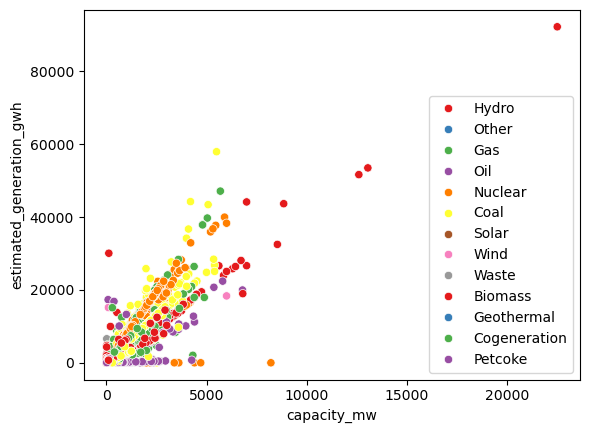

In [46]:
plt.Figure(figsize=(12, 8))
sns.scatterplot(x='capacity_mw', y='estimated_generation_gwh', hue='fuel1', data=df_nonZero, palette='Set1')

plt.legend()
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_3880\2297147412.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fuel1', y='estimated_generation_gwh', data=df_nonZero, palette='Set1')


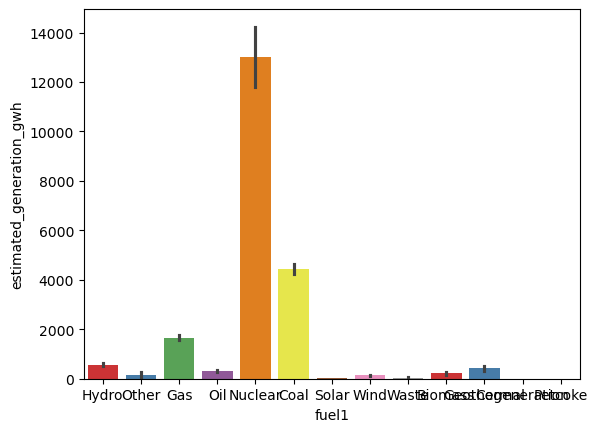

In [43]:
plt.Figure(figsize=(16, 8))
sns.barplot(x='fuel1', y='estimated_generation_gwh', data=df_nonZero, palette='Set1')

plt.show()


<Axes: >

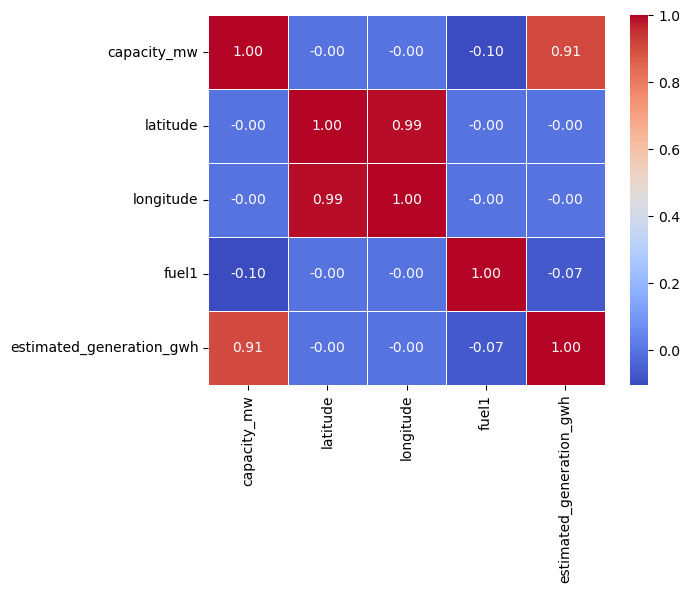

In [53]:
plant_numberic = df_nonZero.select_dtypes('number')
correlation_matrix = plant_numberic.corr()

plt.Figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)